# 22 — What goes with neuropil loss in white-matter lesions?

Notebook 20: white-matter (WM) lesion cells have less ATP1A1 neuropil around them than healthy WM of the same piece,
robust to crowding, composition, the tissue surface and channel. Here: **which cells and which damaging programs sit
where the loss is deepest?** Cross-sectional, so these are associations that point at candidates, not causes.

1. **Local composition and programs, within lesions.** Dense WM lesion cells only (curated lesion niches, where
   notebook 20 found the loss), within each tissue piece: each cell's neuropil value relative to healthy WM within
   150 µm (log local ATP1A1 index) against its 30-cell
   neighbourhood: cell-type shares and gene programs scored from the neighbours' RNA, among them candidate injury
   mechanisms (NOX2/oxidative burst, complement, cytotoxic T cells, cytokines, proteases, lipid-laden phagocytes,
   leaky vessels as an oedema proxy). Adjusted for cellularity and depth from the surface. **Control:** the same for the
   DAPI territory index; a genuine neuropil effect should show for ATP1A1, not for DAPI.
2. **Distance dose–response:** neuropil vs distance to the nearest macrophage, T cell, B cell, neutrophil, NOX2-high
   myeloid cell, reactive astrocyte; myelinating oligodendrocytes as a reference.
3. **Across animals and stages:** does an animal's WM neuropil loss follow the make-up of its WM lesions, and is it
   already there at onset?
4. **The tissue:** ATP1A1 in WM lesions with the top candidate cells marked.

**Caveat (added after notebook 20, section 9).** The WM neuropil loss turned out to be confined to lesions within
~75 µm of grey matter (×0.80–0.88 at matched distance); deeper WM lesions show none, and the larger unmatched loss
was partly distance to grey matter. Section 1 therefore adjusts for distance to grey matter; sections 2–3 use the
unmatched local index and should be read as descriptive of where lesion cells sit, not as drivers.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/22_neuropil_drivers.ipynb"
OUT = ROOT / "results" / "22_neuropil_drivers"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125
WM = ["WM", "WM_Meningeal"]
K = 30

PROGRAMS = {
    "NOX2 / oxidative burst": ["Cybb", "Ncf1", "Ncf4", "Nos2"],
    "complement": ["C3", "C4b", "C3ar1", "Itgam"],
    "cytotoxic T/NK": ["Gzmb", "Gzma", "Gzmk", "Prf1", "Ifng", "Fasl"],
    "inflammatory cytokines": ["Tnf", "Ccl2", "Ccl5", "Cxcl10", "Il17a", "Csf2"],
    "proteases (MMP)": ["Mmp9", "Mmp12", "Ctss"],
    "lipid-laden phagocyte": ["Trem2", "Lpl", "Cd36", "Gpnmb", "Cd68", "Axl", "Mertk"],
    "MHC-II": ["H2-Aa", "H2-Ab1", "H2-Eb1", "Cd74"],
    "interferon": ["Ifit1", "Ifit3", "Isg15", "Irf7", "Stat1"],
    "leaky vessels (Plvap)": ["Plvap"],
    "astrocyte reactivity": ["C3", "Gfap", "Serpina3n", "Cd44", "Osmr", "Timp1"],
    "myelin": ["Mbp", "Mog", "Mag", "Cldn11", "Mal", "Opalin"],
}

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Anno_L2",
             "Global_anatomical_region", "Curated_niche_state", "x_centroid", "y_centroid"]].copy()
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state", "ctype"]])
gi = {g: i for i, g in enumerate(a.var_names)}
X = a.X.tocsc()
prog = pd.DataFrame(index=obs.index)
for p, genes in PROGRAMS.items():
    gs = [g for g in genes if g in gi]
    M = X[:, [gi[g] for g in gs]].toarray()
    prog[p] = ((M - M.mean(0)) / M.std(0)).mean(1)
del X, a
print({p: len([g for g in v if g in gi]) for p, v in PROGRAMS.items()})

# neighbourhood composition (notebook 10 cache) + neighbourhood means of the new programs (same 30-NN definition)
nb = pd.read_parquet(ROOT / "data" / "lesion10" / "neighbourhoods.parquet")
frac_cols = [c for c in nb.columns if c.startswith("frac ")]
pm = np.zeros((len(obs), prog.shape[1]), np.float32)
P = prog.to_numpy(np.float32)
for _, idx in obs.groupby("meta_sample_id", observed=True).indices.items():
    xy = obs[["x_centroid", "y_centroid"]].to_numpy()[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K, len(idx)))
    pm[idx] = P[idx][nn].mean(1)
nbp = pd.DataFrame(pm, index=obs.index, columns=[f"prog {p}" for p in PROGRAMS])

{'NOX2 / oxidative burst': 4, 'complement': 4, 'cytotoxic T/NK': 6, 'inflammatory cytokines': 6, 'proteases (MMP)': 3, 'lipid-laden phagocyte': 7, 'MHC-II': 4, 'interferon': 5, 'leaky vessels (Plvap)': 1, 'astrocyte reactivity': 6, 'myelin': 6}


In [3]:
cols = ["section_id", "segmentation_method", "edge_um", "bnd_terr_mean", "bnd_scale", "bnd_bg_local",
        "dapi_terr_mean", "dapi_scale", "dapi_bg_local", "centroid_x_px", "centroid_y_px"]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=cols)
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].join(obs, how="inner")
fa = fa[fa.Global_anatomical_region.isin(WM)]
for c in ["bnd", "dapi"]:
    raw = fa[f"{c}_terr_mean"] * fa[f"{c}_scale"] + fa[f"{c}_bg_local"]
    fa[f"{c}_index"] = raw / raw.groupby(fa.meta_sample_id.astype(str)).transform("median")
    fa[f"log_{c}"] = np.log(fa[f"{c}_index"].clip(lower=1e-3))
other = pd.Series(np.inf, index=fa.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pcs = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pcs):
        m = pcs == p
        if not m.all():
            idx = fa.index.intersection(g.index[m])
            if len(idx):
                other[idx] = cKDTree(xy[~m]).query(fa.loc[idx, ["x_centroid", "y_centroid"]].to_numpy())[0]
fa = fa[other >= 20].join(nb[frac_cols + ["log cellularity"]]).join(nbp)
fa["log_depth"] = np.log1p(fa.edge_um.clip(lower=0))
# Notebook 20: the loss is local to dense lesion cores (curated niches) and part of the piece-wide contrast is tract
# anatomy. Outcome here: each WM lesion cell's ATP1A1 territory ÷ the median of healthy (physiological) WM cells within
# 150 µm in the same piece (local index), so tract differences can't masquerade as drivers. DAPI likewise (control).
fa["les"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys"] = fa.Curated_niche_state.astype(str) == "Physiological"
for c in ["bnd", "dapi"]:
    fa[f"local_{c}"] = np.nan
for pc, g in fa.groupby("meta_sample_id", observed=True):
    Lc, Hc = g[g.les], g[g.phys]
    if len(Lc) < 50 or len(Hc) < 50:
        continue
    nbrs = cKDTree(Hc[["x_centroid", "y_centroid"]].to_numpy()).query_ball_point(Lc[["x_centroid", "y_centroid"]].to_numpy(), 150)
    for c in ["bnd", "dapi"]:
        hv = Hc[f"{c}_index"].to_numpy()
        ref = np.array([np.median(hv[n]) if len(n) >= 20 else np.nan for n in nbrs])
        fa.loc[Lc.index, f"local_{c}"] = Lc[f"{c}_index"].to_numpy() / ref
for c in ["bnd", "dapi"]:
    fa[f"log_{c}"] = np.log(fa[f"local_{c}"].where(fa[f"local_{c}"] > 0))
# distance to grey matter (notebook 20, section 9: ATP1A1 falls steeply with distance from grey matter, and the lesion
# loss is confined to the first ~75 µm); used as a covariate below
GM = ["GM", "DorsalHorn", "VentralHorn"]
fa["d_gm"] = np.nan
for pc, g in obs.groupby("meta_sample_id", observed=True):
    gm = g[g.Global_anatomical_region.astype(str).isin(GM)]
    idx = fa.index[fa.meta_sample_id == pc]
    if len(gm) >= 20 and len(idx):
        fa.loc[idx, "d_gm"] = cKDTree(gm[["x_centroid", "y_centroid"]].to_numpy()).query(
            fa.loc[idx, ["x_centroid", "y_centroid"]].to_numpy())[0]
fa["log_dgm"] = np.log1p(fa.d_gm)
L = fa[fa.les & fa.log_bnd.notna() & np.isfinite(fa.log_bnd)].copy()
print(len(fa), "WM cells;", len(L), "WM lesion cells in", L.meta_sample_id.nunique(), "pieces")

543547 WM cells; 24433 WM lesion cells in 107 pieces


## 1. Local composition and programs, within WM lesions
Per tissue piece (≥ 200 WM lesion cells): partial Spearman ρ between each neighbourhood feature and the cell's log
ATP1A1 index, adjusting for log cellularity, log depth from the surface and log distance to grey matter (added
after notebook 20, section 9 showed the WM loss is confined to the grey/white border); the same for the DAPI index
(control). Per animal: median
over its pieces; summary over animals. Negative ρ for ATP1A1 = more of this feature, less neuropil.

In [4]:
FEATS = [c for c in frac_cols if c.replace("frac ", "") in
         ["MDM", "Microglia", "CAM", "DC", "T cell", "B cell", "Neutrophil", "NK/DC", "Reactive astro", "Homeostatic astro",
          "MOL", "NFOL", "DAO", "OPC/COP", "EAE fibroblast", "Fibroblast", "Endothelial", "VSMC"]] + list(nbp.columns)
COV = ["log cellularity", "log_depth", "log_dgm"]  # distance to grey matter added after notebook 20, section 9


def partial_rho(g, x, y):
    d = g[[x, y] + COV].dropna()
    if len(d) < 100 or d[x].std() == 0:
        return np.nan
    Z = np.c_[np.ones(len(d)), d[COV].to_numpy()]
    rx = d[x].to_numpy() - Z @ np.linalg.lstsq(Z, d[x].to_numpy(), rcond=None)[0]
    ry = d[y].to_numpy() - Z @ np.linalg.lstsq(Z, d[y].to_numpy(), rcond=None)[0]
    return spearmanr(rx, ry).statistic


rows = []
for pc, g in L.groupby("meta_sample_id", observed=True):
    if len(g) < 200:
        continue
    for f in FEATS:
        rows.append(dict(piece=pc, sample_name=g.sample_name.iloc[0], feature=f,
                         rho_atp1a1=partial_rho(g, f, "log_bnd"), rho_dapi=partial_rho(g, f, "log_dapi")))
loc = pd.DataFrame(rows)
an = loc.groupby(["sample_name", "feature"])[["rho_atp1a1", "rho_dapi"]].median().reset_index()
summ = []
for f, g in an.groupby("feature"):
    v, w = g.rho_atp1a1.dropna(), g.rho_dapi.dropna()
    summ.append(dict(feature=f.replace("frac ", "share: ").replace("prog ", "program: "), animals=len(v),
                     rho_ATP1A1=v.median(), share_negative=(v < 0).mean(),
                     p=wilcoxon(v).pvalue if len(v) >= 6 else np.nan, rho_DAPI_control=w.median()))
summ = pd.DataFrame(summ).sort_values("rho_ATP1A1")
summ["specific (ATP1A1 − DAPI)"] = summ.rho_ATP1A1 - summ.rho_DAPI_control
summ.to_csv(OUT / "local_drivers.csv", index=False)
summ.round(3)

,feature,animals,rho_ATP1A1,share_negative,p,rho_DAPI_control,specific (ATP1A1 − DAPI)
24,program: interferon,37,-0.088,0.649,0.011,0.003,-0.091
13,share: Neutrophil,5,-0.084,1.000,NaN,-0.040,-0.044
2,share: DAO,37,-0.079,0.676,0.002,-0.058,-0.021
20,program: astrocyte reactivity,37,-0.060,0.730,0.012,-0.030,-0.030
26,program: lipid-laden phagocyte,37,-0.049,0.649,0.059,0.025,-0.073
21,program: complement,37,-0.047,0.676,0.018,0.006,-0.053
10,share: Microglia,37,-0.034,0.568,0.172,-0.031,-0.004
28,program: proteases (MMP),37,-0.029,0.595,0.114,0.020,-0.049
15,share: Reactive astro,37,-0.028,0.568,0.177,-0.008,-0.020
12,share: NK/DC,27,-0.023,0.593,0.427,0.027,-0.050


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/22_neuropil_drivers/local_drivers.png')

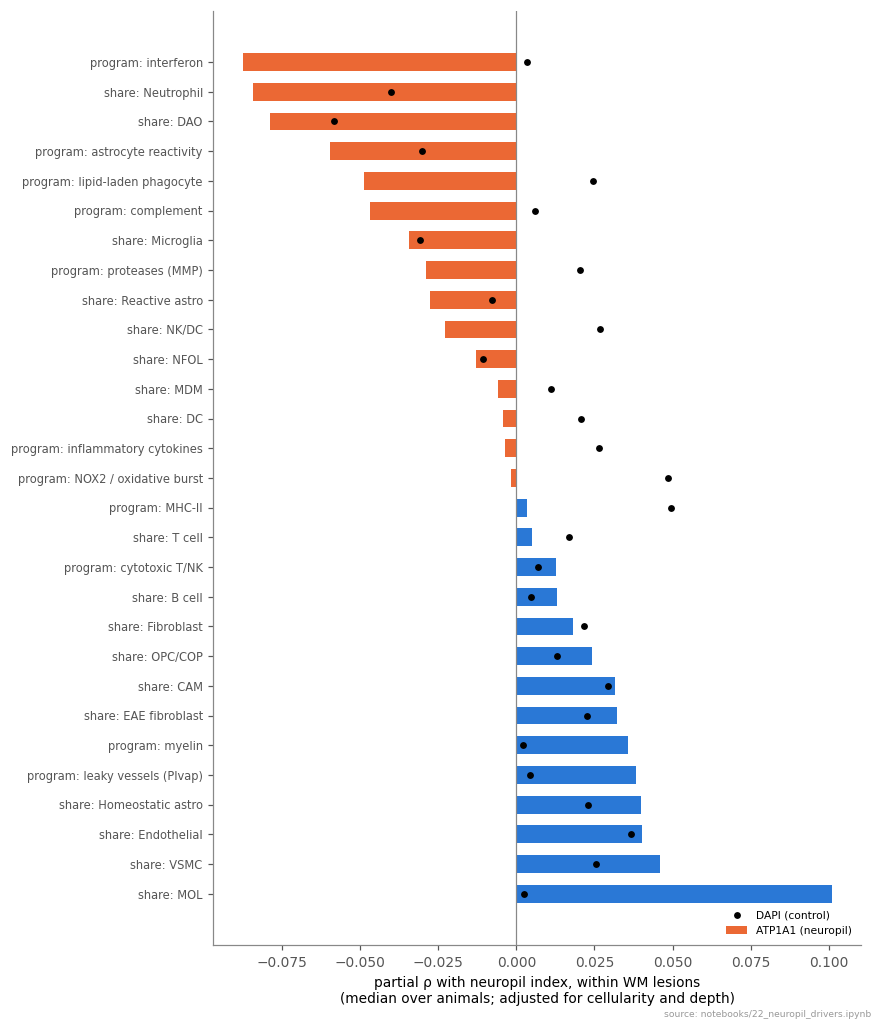

In [5]:
s = summ.dropna(subset=["rho_ATP1A1"])
fig, ax = plt.subplots(figsize=(8, 0.28 * len(s) + 1.2))
y = np.arange(len(s))
ax.barh(y, s.rho_ATP1A1, color=[COL[1] if v < 0 else COL[0] for v in s.rho_ATP1A1], height=0.6, label="ATP1A1 (neuropil)")
ax.scatter(s.rho_DAPI_control, y, color="black", s=12, zorder=3, label="DAPI (control)")
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(y, s.feature, fontsize=7.5); ax.invert_yaxis()
ax.set_xlabel("partial ρ with neuropil index, within WM lesions\n(median over animals; adjusted for cellularity and depth)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "local_drivers", OUT, SRC)

**Together.** The candidates are correlated (macrophage-rich neighbourhoods are also NOX2-, MMP- and lipid-high). Per
piece, all top candidates in one linear model (standardised, plus covariates); median coefficient over pieces shows
which still carry information when the others are accounted for.

In [6]:
top = list(summ.sort_values("p").feature.head(10))
inv = {f.replace("frac ", "share: ").replace("prog ", "program: "): f for f in FEATS}
topf = [inv[t] for t in top]
rows = []
for pc, g in L.groupby("meta_sample_id", observed=True):
    d = g[topf + COV + ["log_bnd"]].dropna()
    if len(d) < 300:
        continue
    Xd = d[topf + COV].to_numpy()
    sd = Xd.std(0); sd[sd == 0] = 1
    Xs = np.c_[np.ones(len(d)), (Xd - Xd.mean(0)) / sd]
    beta = np.linalg.lstsq(Xs, (d.log_bnd - d.log_bnd.mean()) / d.log_bnd.std(), rcond=None)[0][1:len(topf) + 1]
    rows.append(dict(piece=pc, sample_name=g.sample_name.iloc[0], **dict(zip(top, beta))))
mv = pd.DataFrame(rows).groupby("sample_name")[top].median()
mvs = pd.DataFrame({"median_beta": mv.median(), "share_negative": (mv < 0).mean(),
                    "p": [wilcoxon(mv[c].dropna()).pvalue for c in top]}).sort_values("median_beta")
mvs.to_csv(OUT / "multivariable.csv")
mvs.round(3)

,median_beta,share_negative,p
share: DAO,-0.064,0.750,0.037
program: interferon,-0.043,0.625,0.565
program: complement,-0.006,0.500,0.345
program: lipid-laden phagocyte,-0.003,0.500,0.509
program: astrocyte reactivity,0.002,0.500,0.790
program: leaky vessels (Plvap),0.013,0.375,0.178
share: EAE fibroblast,0.026,0.250,0.077
share: Homeostatic astro,0.046,0.333,0.053
share: Endothelial,0.055,0.333,0.944
share: MOL,0.068,0.250,0.034


## 2. Distance dose–response
WM lesion cells: neuropil index against distance to the nearest cell of each kind (same piece), median over pieces
of the per-piece median per distance bin. NOX2-high myeloid = top quartile of the NOX2 program among macrophages,
microglia and DC.

,target,pieces,near_0_20um,far_50_150um,ratio,p
0,microglia,61,0.840,0.847,0.988,0.316
1,T cell,8,0.819,0.828,1.005,0.742
3,reactive astrocyte,38,0.890,0.864,1.017,0.204
4,MOL (reference),53,0.876,0.829,1.042,0.008
2,NOX2-high myeloid,7,0.887,0.838,1.058,0.469


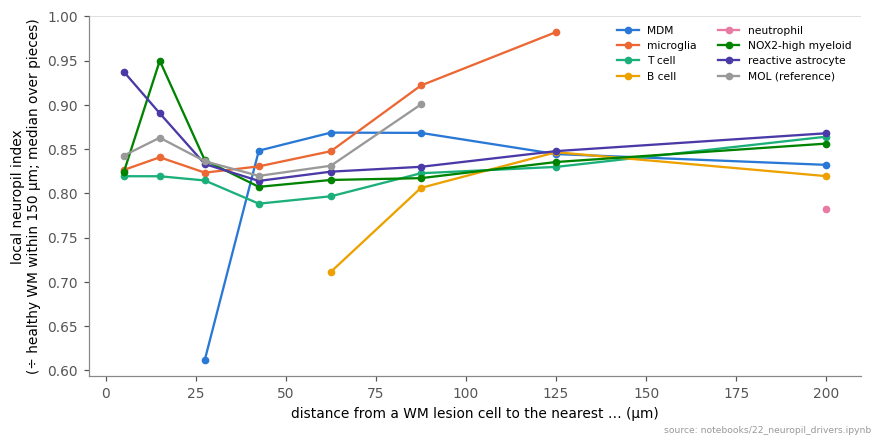

In [7]:
my = obs.Anno_L1_curated.isin(["Myeloid", "DC"])
nox_hi = my & (prog["NOX2 / oxidative burst"] > prog.loc[my, "NOX2 / oxidative burst"].quantile(0.75))
TARGETS = {"MDM": obs.Anno_L2 == "MDM", "microglia": obs.Anno_L2 == "Microglia", "T cell": obs.ctype == "T cell",
           "B cell": obs.ctype == "B cell", "neutrophil": obs.Anno_L1_curated == "Neutrophil",
           "NOX2-high myeloid": nox_hi, "reactive astrocyte": obs.Anno_L2 == "Reactive_AST",
           "MOL (reference)": obs.Anno_L2 == "MOL"}
for t, m in TARGETS.items():
    d = pd.Series(np.nan, index=L.index)
    for pc, g in obs.groupby("meta_sample_id", observed=True):
        f = L.index.intersection(g.index)
        tg = g[m.reindex(g.index).fillna(False).to_numpy()]
        if len(f) == 0 or len(tg) < 3:
            continue
        dd, _ = cKDTree(tg[["x_centroid", "y_centroid"]].to_numpy()).query(L.loc[f, ["x_centroid", "y_centroid"]].to_numpy(), k=2)
        d[f] = np.where(dd[:, 0] < 1e-6, dd[:, 1], dd[:, 0])
    L[f"dist {t}"] = d
BINS = [0, 10, 20, 35, 50, 75, 100, 150, 250]
mids = [5, 15, 27.5, 42.5, 62.5, 87.5, 125, 200]
fig, ax = plt.subplots(figsize=(8, 4))
rows = []
for k, t in enumerate(TARGETS):
    b = pd.cut(L[f"dist {t}"], BINS)
    m = L.groupby([L.meta_sample_id.astype(str), b], observed=True).local_bnd.agg(["median", "size"])
    m = m[m["size"] >= 20]["median"].unstack().reindex(columns=b.cat.categories)
    ax.plot(mids, m.median().values, marker="o", ms=4, color=COL[k % 8] if "reference" not in t else "#999999", label=t)
    near, far = m.iloc[:, :2].mean(1), m.iloc[:, 4:7].mean(1)
    ok = near.notna() & far.notna()
    if ok.sum() >= 6:
        rows.append(dict(target=t, pieces=int(ok.sum()), near_0_20um=near[ok].median(), far_50_150um=far[ok].median(),
                         ratio=(near[ok] / far[ok]).median(), p=wilcoxon(near[ok] - far[ok]).pvalue))
ax.axhline(1, color="#dddddd", lw=0.6)
ax.set(xlabel="distance from a WM lesion cell to the nearest … (µm)", ylabel="local neuropil index\n(÷ healthy WM within 150 µm; median over pieces)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plotting.save_fig(fig, "distance_dose_response", OUT, SRC)
dose = pd.DataFrame(rows).sort_values("ratio")
dose.to_csv(OUT / "distance_near_vs_far.csv", index=False)
dose.round(3)

## 3. Across animals and stages
Per animal: WM neuropil loss (median local index of its dense WM lesion cells) against the
make-up of its WM lesions, and by stage.

In [8]:
rows = []
for anl, g in fa.groupby("sample_name", observed=True):
    les_ = g[g.les & g.local_bnd.notna() & np.isfinite(g.local_bnd)]
    if len(les_) < 100:
        continue
    rows.append(dict(animal=anl, stage=g.stage.iloc[0], arm=g.arm.iloc[0],
                     loss=les_.local_bnd.median(),
                     **{f.replace("frac ", "share: ").replace("prog ", "program: "): les_[f].mean() for f in topf}))
A = pd.DataFrame(rows).set_index("animal")
A.to_csv(OUT / "per_animal.csv")
cor = pd.DataFrame({c: dict(rho=spearmanr(A.loss, A[c]).statistic, p=spearmanr(A.loss, A[c]).pvalue)
                    for c in A.columns if c not in ("stage", "arm", "loss")}).T.sort_values("rho")
print(f"{len(A)} animals; ρ < 0 = more of this in its WM lesions, more neuropil loss")
display(cor.round(3))
order = ["OS1", "ONSET1", "ONSET2", "PEAK1", "PEAK2", "PEAK2_MILD", "PEAK3", "REMISSION1", "MONOPHASIC", "REMISSION2",
         "REMISSION2_LONG", "MILD16", "SEVERE16", "MILD30", "SEVERE30"]
A.groupby("stage").loss.agg(["median", "size"]).reindex([s for s in order if s in set(A.stage)]).round(3)

43 animals; ρ < 0 = more of this in its WM lesions, more neuropil loss


,rho,p
share: MOL,-0.516,0.000
program: complement,-0.424,0.005
program: lipid-laden phagocyte,-0.296,0.054
share: DAO,-0.152,0.329
program: leaky vessels (Plvap),-0.020,0.900
share: Homeostatic astro,0.007,0.966
program: astrocyte reactivity,0.109,0.488
share: Endothelial,0.269,0.081
program: interferon,0.359,0.018
share: EAE fibroblast,0.478,0.001


,median,size
stage,,
OS1,0.918,5
ONSET1,0.925,2
ONSET2,0.984,2
PEAK1,0.898,2
PEAK2,0.730,1
PEAK2_MILD,0.668,2
PEAK3,0.808,3
REMISSION1,0.724,5
MONOPHASIC,0.837,4


## 4. The tissue
A random deep WM lesion field (seed 0; ≥ 100 µm from the surface, ≥ 150 WM lesion cells within 100 µm): the ATP1A1
channel (magma) with the top candidate cells marked, next to the per-cell neuropil index map of the same field.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/22_neuropil_drivers/lesion_field_candidates.png')

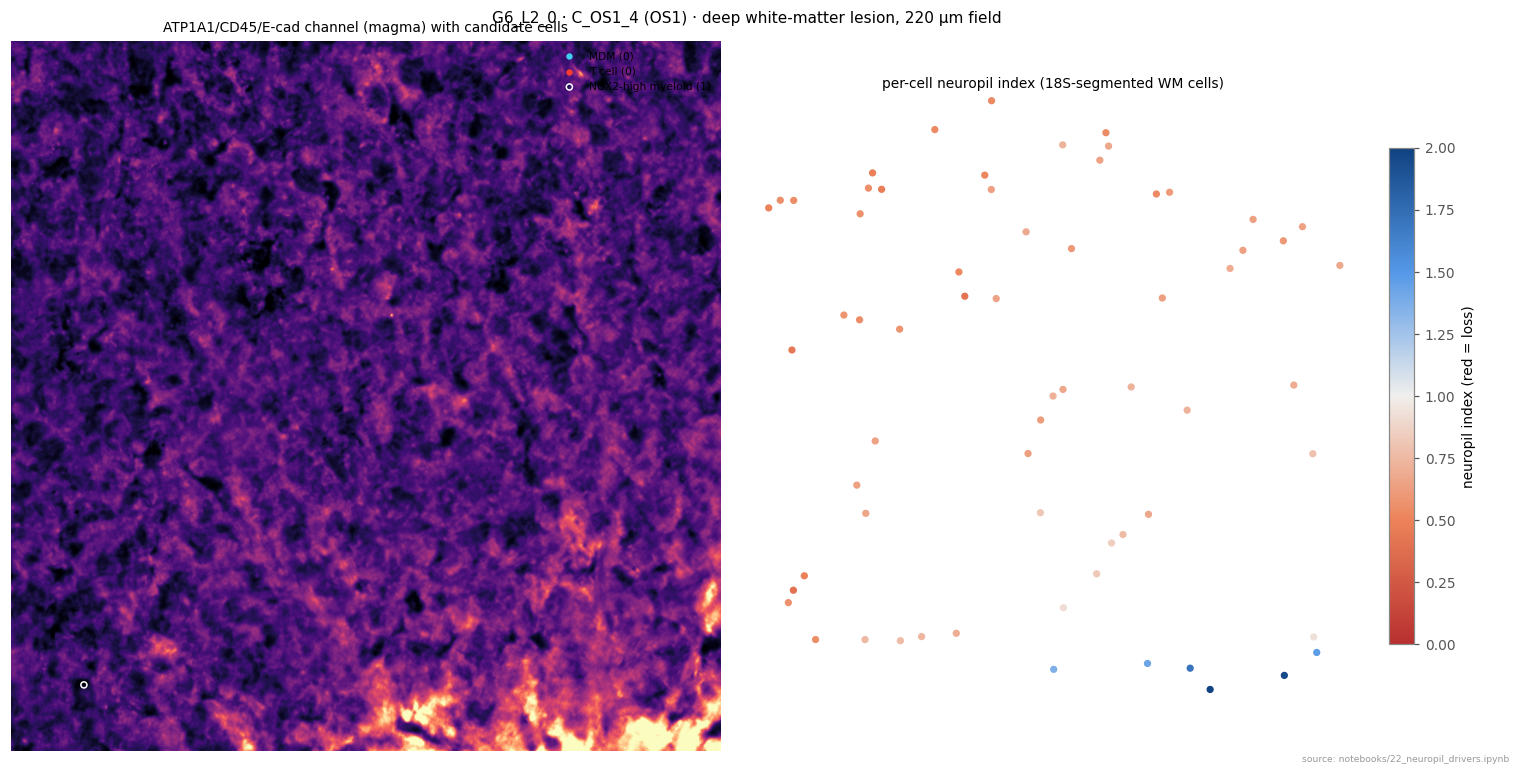

In [9]:
bundles = find_bundles(data.load_config())
deep = L[(L.edge_um > 100)]
cand = []
for pc, g in deep.groupby("meta_sample_id", observed=True):
    if len(g) >= 150:
        cand.append(g.sample(1, random_state=0).iloc[0])
cell = pd.DataFrame(cand).sample(1, random_state=0).iloc[0]
half = 110
cx, cy = cell.x_centroid, cell.y_centroid
b = XeniumBundle(bundles[str(cell.section_id)])
img, cm, _ = b.read_window(int(cy / PX) - int(half / PX), int(cx / PX) - int(half / PX), int(2 * half / PX), int(2 * half / PX))
win = obs[(obs.meta_sample_id == cell.meta_sample_id) & obs.x_centroid.between(cx - half, cx + half)
          & obs.y_centroid.between(cy - half, cy + half)]
fw = fa[fa.index.isin(win.index)]
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
im = img[1]
axs[0].imshow(np.clip(im / np.percentile(im, 99.5), 0, 1), cmap="magma", extent=(cx - half, cx + half, cy + half, cy - half))
for t, colr, sz in [("MDM", "#3fd0f0", 10), ("T cell", "#ff3b30", 10), ("NOX2-high myeloid", "#ffffff", 16)]:
    w = win[TARGETS[t].reindex(win.index).fillna(False)]
    axs[0].scatter(w.x_centroid, w.y_centroid, s=sz, facecolors="none" if t == "NOX2-high myeloid" else colr,
                   edgecolors=colr, lw=1, label=f"{t} ({len(w)})")
axs[0].legend(fontsize=7, loc="upper right")
axs[0].set_title("ATP1A1/CD45/E-cad channel (magma) with candidate cells", fontsize=9)
sc_ = axs[1].scatter(fw.x_centroid, fw.y_centroid, c=fw.bnd_index.clip(0, 2), cmap=plotting.DIV.reversed(), vmin=0, vmax=2, s=14)
axs[1].set_xlim(cx - half, cx + half); axs[1].set_ylim(cy + half, cy - half); axs[1].set_aspect("equal")
fig.colorbar(sc_, ax=axs[1], shrink=0.7, label="neuropil index (red = loss)")
axs[1].set_title("per-cell neuropil index (18S-segmented WM cells)", fontsize=9)
for ax_ in axs:
    ax_.axis("off")
fig.suptitle(f"{cell.meta_sample_id} · {cell.sample_name} ({cell.stage}) · deep white-matter lesion, 220 µm field", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "lesion_field_candidates", OUT, SRC)

## Findings

> **No driver found; weak link to oligodendrocyte state (exploratory).** Within WM lesions, adjusted for cellularity,
> depth and distance to grey matter, no immune cell type or damaging program tracks the local neuropil index: shares
> of macrophages, microglia, T and B cells and the NOX2, cytokine, MMP and cytotoxic programs all have |ρ| < 0.04, and
> neuropil does not change with distance to the nearest MDM, T cell, NOX2-high myeloid cell or reactive astrocyte
> (near ÷ far ×0.99–1.06). The only consistent associations are small: more mature oligodendrocytes (MOL) go with
> more neuropil (ρ +0.10, p = 0.009; multivariable β +0.07) and more disease-associated oligodendrocytes (DAO) and a
> higher interferon program with less (ρ −0.08 and −0.09). DAPI does not show these, so they are ATP1A1-specific,
> but at |ρ| ≈ 0.1 they explain ~1 % of the variation.
>
> **Context.** Notebook 20, section 9 later showed the WM neuropil loss is confined to lesions within ~75 µm of grey
> matter; most WM lesion cells analysed here lie deeper, where there is no loss to explain. A driver analysis
> restricted to the border would have few cells per piece. The answer for now: the loss is not explained by any
> particular infiltrating cell type in its neighbourhood.